In [6]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

In [7]:
img_matrix = cv2.imread('image.jpg')

print(img_matrix.shape)

(183, 275, 3)


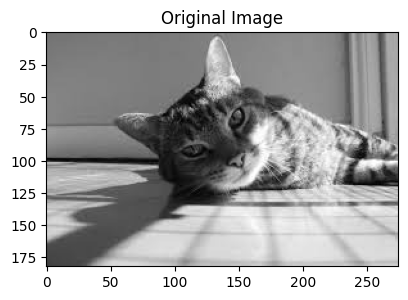

In [8]:
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_matrix)

In [9]:
#Scaling image
scaledImg = cv2.resize(img_matrix, None, fx = 0.5, fy = 0.5)

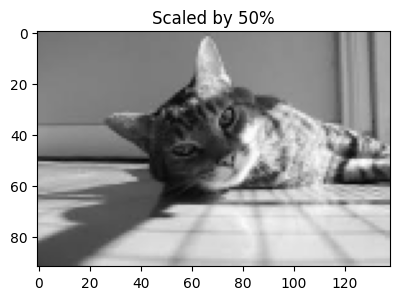

In [10]:
plt.figure(figsize = (10, 5))
plt.subplot(1,2,1)
plt.title('Scaled by 50%')
plt.imshow(scaledImg)

In [11]:
#Translation
tx, ty = 50, 30
translationMatrix = np.float32([[1,0,tx], [0, 1, ty]])
translatedImg = cv2.warpAffine(img_matrix, translationMatrix, (275, 183))

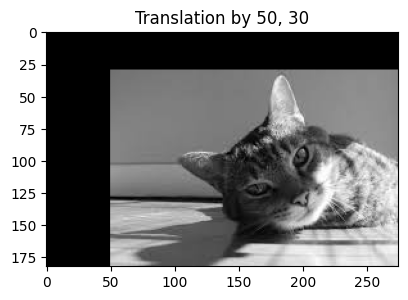

In [12]:
plt.figure(figsize = (10, 5))
plt.subplot(1,2,1)
plt.title(f'Translation by {tx}, {ty}')
plt.imshow(translatedImg)

In [13]:
#Rotation
center = (275//2, 183//2)
angle = -45
scale = 1.0

rotatedMatrix = cv2.getRotationMatrix2D(center, angle, scale)
rotatedImg = cv2.warpAffine(img_matrix, rotatedMatrix, (275, 183))

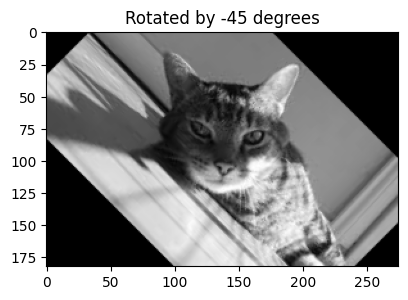

In [14]:
plt.figure(figsize = (10, 5))
plt.subplot(1,2,1)
plt.title(f'Rotated by {angle} degrees')
plt.imshow(rotatedImg)

In [15]:
#Cropping
startY, endY = 50, 150
startX, endX = 100, 250
croppedImg = img_matrix[startY : endY, startX : endX]

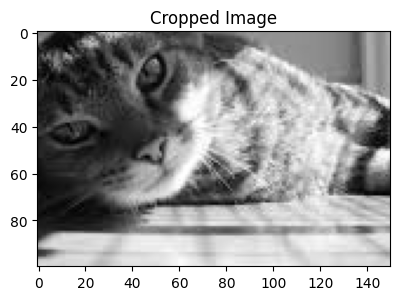

In [16]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Cropped Image")
plt.imshow(croppedImg)


In [17]:
#Flipping
flipped_h = cv2.flip(img_matrix, 1)
flipped_v = cv2.flip(img_matrix, 0)
flipped_both = cv2.flip(img_matrix, -1)

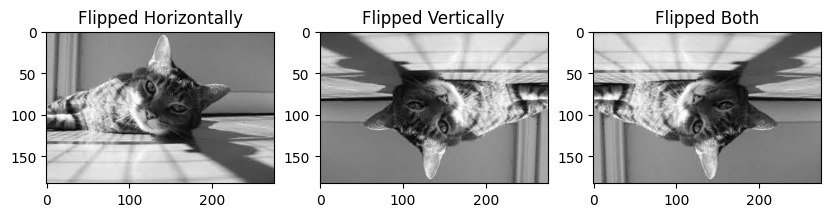

In [18]:
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.title('Flipped Horizontally')
plt.imshow(flipped_h)
plt.subplot(1,3,2)
plt.title('Flipped Vertically')
plt.imshow(flipped_v)
plt.subplot(1,3,3)
plt.title('Flipped Both')
plt.imshow(flipped_both)

In [19]:
#Change Hue, Saturation
img2_matrix = cv2.imread('image copy.jpg')

hsv_image = cv2.cvtColor(img2_matrix, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv_image)
saturation_factor = 0.5
s = s * saturation_factor
s = np.clip(s, 0, 255)
s = s.astype(np.uint8)
sModifiedImg = cv2.merge([h, s, v])
saturatedImg = cv2.cvtColor(sModifiedImg, cv2.COLOR_HSV2RGB)

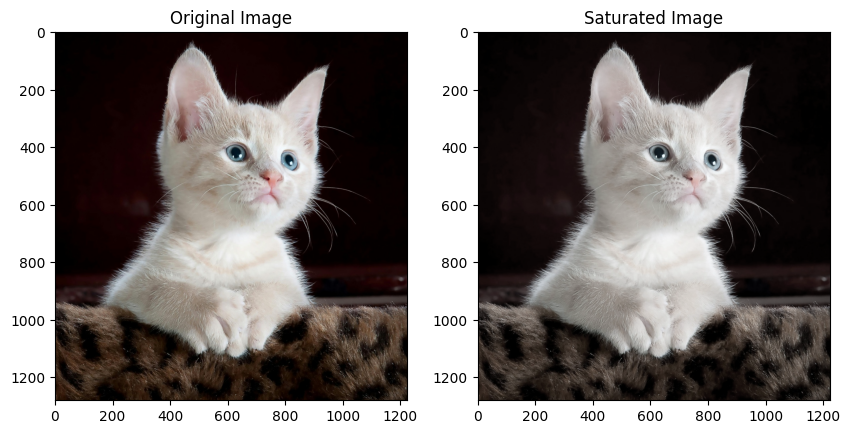

In [20]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img2_matrix, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.title("Saturated Image")
plt.imshow(saturatedImg)

In [21]:
gaussian_filtered = cv2.GaussianBlur(img_matrix, (5, 5), 0)

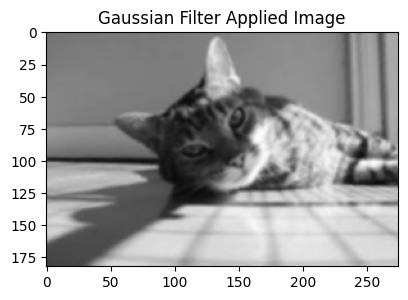

In [25]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Gaussian Filter Applied Image")
plt.imshow(gaussian_filtered)

In [23]:
#Sobel edge detection
img2_matrix = cv2.cvtColor(img2_matrix, cv2.COLOR_BGR2RGB)
sobelx = cv2.Sobel(img2_matrix, cv2.CV_64F, 1, 0, ksize=3)  # X direction
sobely = cv2.Sobel(img2_matrix, cv2.CV_64F, 0, 1, ksize=3)  # Y direction
sobel = cv2.magnitude(sobelx, sobely)  # Combine

# 2. Laplacian edge detection
laplacian = cv2.Laplacian(img2_matrix, cv2.CV_64F)

# 3. Canny edge detection
canny = cv2.Canny(img2_matrix, 100, 200)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..970.8769231988161].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-583.0..409.0].


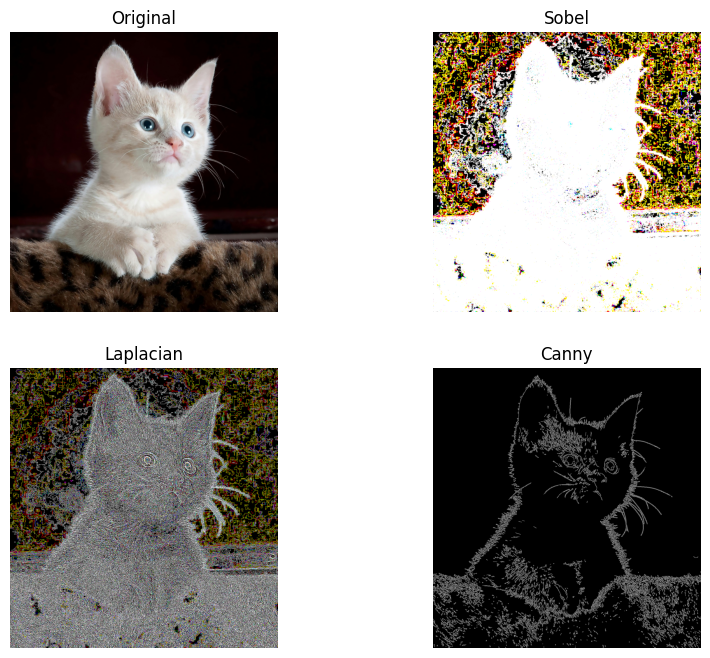

In [24]:
titles = ['Original', 'Sobel', 'Laplacian', 'Canny']
images = [img2_matrix, sobel, laplacian, canny]

plt.figure(figsize=(10, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()